<a href="https://colab.research.google.com/github/bogdanbabych/experiments_NLTK/blob/main/part2_word_embeddings_v12_HIS_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Vectors

Word vectors (also known as 'word embeddings') are one of the most popular kinds of AI models. They are extremely useful in many domains. In essence, a word vector is a set of numbers that attempt to capture the meaning of a word. In typical implementations, each word is represented by a set of 200-300 numbers. In linear algebra, a one-dimensional array of numbers is known as a 'vector', hence these sets of numbers representing words' meanings are known as 'word vectors'.

Using neural networks, we can expose the computer to a large amount of text, and allow it to learn an appropriate set of numbers for each word it encounters. In this notebook, we will learn about the most famous of all word vector algorithms, `word2vec`, which was first described by Tomas Mikolov and his team in 2013:

* Tomas Mikolov, Ilya Sutskever, and others, ‘Distributed Representations of Words and Phrases and Their Compositionality’, in Advances in Neural Information Processing Systems 26, ed. by C. J. C. Burges and others (Curran Associates, Inc., 2013), pp. 3111–19 <http://papers.nips.cc/paper/5021-distributed-representations-of-words-and-phrases-and-their-compositionality.pdf>
* Tomas Mikolov, Kai Chen, and others, ‘Efficient Estimation of Word Representations in Vector Space’, ArXiv:1301.3781 Cs, 2013 <http://arxiv.org/abs/1301.3781>.

In fact, `word2vec` is not a single algorithm, but rather a family of similar algorithms. In this session we will consider just the most famous `word2vec` algorithm, namely the `skip-gram model` trained using `negative sampling`.

## Applications of Word Vectors

Word vectors allow the computer to 'understand' language far more effectively. Rather than seeing each word as simply an arbitrarily different object, a computer using word vectors can analyse each word as a point in 200- or 300-dimenstional space. Words that are similar in meaning will have similar word vectors. And as we will see, the spaces between the word vectors are also significant: the words are arranged in patterns that represent their relationships to one another.

Accordingly, most AI systems that process language now include a word vector layer as part of their architecure. When the system encounters some text (e.g. when you speak to Siri or Alexa), your words are converted into word vectors, *and then* the computer examines what the text says and determines how it should respond.

In the Humanities, word vectors have become a popular modelling tool, because they allow researchers to perform sophisticated analysis on large corpora of text. Some examples include:

* [The Women Writers Vector Toolkit](https://wwp.northeastern.edu/lab/wwvt/index.html)
* William L. Hamilton, Jure Leskovec, and Dan Jurafsky, ‘Diachronic Word Embeddings Reveal Statistical Laws of Semantic Change’, ArXiv:1605.09096 [Cs], 2018 <http://arxiv.org/abs/1605.09096>.
* Ryan Heuser, 'Semantic Networks' <https://ryanheuser.org/word-vectors-4/>

## Training a `word2vec` model in Gensim


It is very easy to train a `word2vec` model in Gensim, which includes Mikolov's original `word2vec` code in its codebase.

### Step 0: Downloading texts
#### 0.1: load an existing text collection...


In [ ]:
!pip install gensim
from gensim.models import Word2Vec # The word2vec model class
import gensim.downloader as api # Allows us to download some free training data

# api.info()

In [2]:
from gensim.models import KeyedVectors

In [ ]:
# loading a large database of word vectors ( pre-built )
word_vectors = api.load('glove-wiki-gigaword-300')

[===========================-----------------------] 55.0% 206.8/376.1MB downloaded

- alternative: download word_vectors from Seafile

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/21e852be230141afbb95/?dl=1
!mv index.html?dl=1 word2vec.wordvectors.vectors.npy

!wget https://heibox.uni-heidelberg.de/f/a0e773c225de42cb9880/?dl=1
!mv index.html?dl=1 word2vec.wordvectors


In [ ]:
del word_vectors

In [ ]:
word_vectors = KeyedVectors.load("word2vec.wordvectors")

## Training own **corpus**
text8 is first 100MB from English wikipedia, 17 million words

The file is downloadable from
http://mattmahoney.net/dc/text8.zip


In [ ]:
corpus = api.load('text8')
# api.info("text8")


In [ ]:
type(corpus)

In [ ]:
# Examine the corpus to see what is there
data = [d for d in corpus]

In [ ]:
len(data)

In [ ]:
len(data[0])

In [ ]:
len(data[1])

In [ ]:
len(data[2])

In [ ]:
print(data[0][:100])

In [ ]:
print(data[1][:100])

In [ ]:
print(data[-2][:100])

#### Step 0.2: load own text collection to be used in training ... (will be added later)...


### Step 1: Set hyperparameters and instantiate model

In [ ]:
my_vector_size = 100 # Dimensionality of the word vectors
window = 5 # How many words either side? (5 = 5 context words either side, i.e. 10 context words in total)
use_skip_gram = 1 # If you set this to 0, then it will create a 'continuous bag of words' model instead
use_softmax = 0 # If you set this to 1, then hierarchical softmax will be used instead of negative sampling
negative_samples = 5 # How many incorrect answers to generate per correct answer when negative sampling

model = Word2Vec(
    vector_size=my_vector_size,
    window=window,
    sg=use_skip_gram,
    hs=use_softmax,
    negative=negative_samples
)

### Step 2: Fit model to corpus

In [ ]:
# build a model
model.build_vocab(corpus)

In [ ]:
# Train the model on the corpus
# model.train(sentences=corpus, epochs=5, total_examples=model.corpus_count)
# runs approximately 10 minutes with 5 epochs...
model.train(corpus, epochs=5, total_examples=model.corpus_count)

# saving the model, zip can be downloaded...
model.save("word2vec5e.model")
# !zip word2vec5e.model.zip word2vec5e.model
# !rm word2vec5e.model

  adding: word2vec5e.model (deflated 10%)


In [ ]:
!rm word2vec5e.model.zip

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/25ee7b47b18f466fb0f0/?dl=1
!mv index.html?dl=1 word2vec5e.model
# !unzip word2vec5e.model.zip

In [ ]:
# modelOwn.train(sentences=corpusOwn, epochs=5, total_examples=modelOwn.corpus_count)

In [ ]:
## !rm word2vec.model

### Step 2: alternative: downloading a pre-trained model

In [ ]:
del model

In [ ]:
model = Word2Vec.load("word2vec5e.model")

In [ ]:
model = Word2Vec.load("word2vec.model")
# model2 = Word2Vec.load("word2vec.model")

In [ ]:
from __future__ import absolute_import, division, print_function
import numpy as np
count = 10000


In [ ]:
word_vectors_matrix = np.ndarray(shape=(count, model.wv.vector_size), dtype='float64')
word_list = []
i = 0
for word in model.wv.index_to_key:
    if i == count:
        break
    word_vectors_matrix[i] = model.wv[word]
    word_list.append(word)
    i = i+1
print("word_vectors_matrix shape is ", word_vectors_matrix.shape)

word_vectors_matrix shape is  (10000, 100)


In [ ]:
#Compress the word vectors into 2D space (2 min)
import sklearn.manifold
tsne = sklearn.manifold.TSNE(n_components=2, random_state=0)
word_vectors_matrix_2d = tsne.fit_transform(word_vectors_matrix)
print("word_vectors_matrix_2d shape is ", word_vectors_matrix_2d.shape)

word_vectors_matrix_2d shape is  (10000, 2)


In [ ]:
import pandas as pd
points = pd.DataFrame(
    [
        (word, coords[0], coords[1])
        for word, coords in [
            (word, word_vectors_matrix_2d[word_list.index(word)])
            for word in word_list
        ]
    ],
    columns=["word", "x", "y"]
)
print("Points DataFrame built")

In [ ]:
points.head(10)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context("poster")

<Axes: xlabel='x', ylabel='y'>

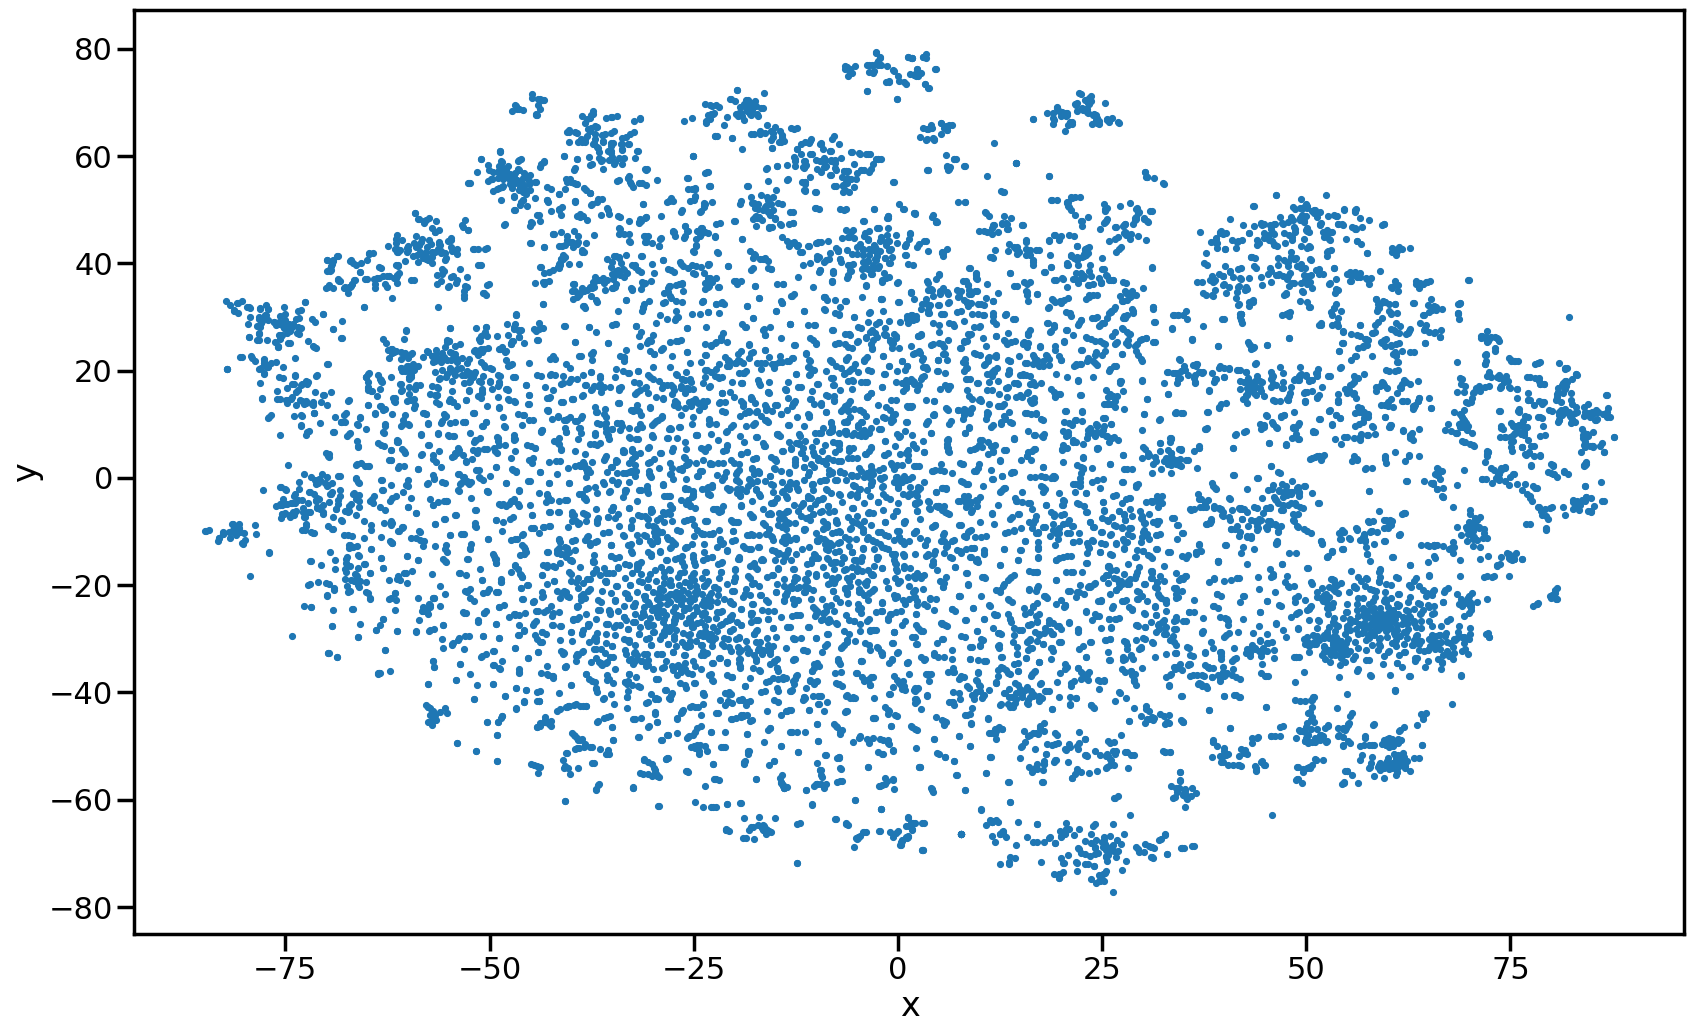

In [ ]:
points.plot.scatter("x", "y", s=10, figsize=(20, 12))

In [ ]:
def plot_region(x_bounds, y_bounds):
    slice = points[
        (x_bounds[0] <= points.x) &
        (points.x <= x_bounds[1]) &
        (y_bounds[0] <= points.y) &
        (points.y <= y_bounds[1])
    ]

    ax = slice.plot.scatter("x", "y", s=35, figsize=(10, 8))
    for i, point in slice.iterrows():
        ax.text(point.x + 0.005, point.y + 0.005, point.word, fontsize=11)

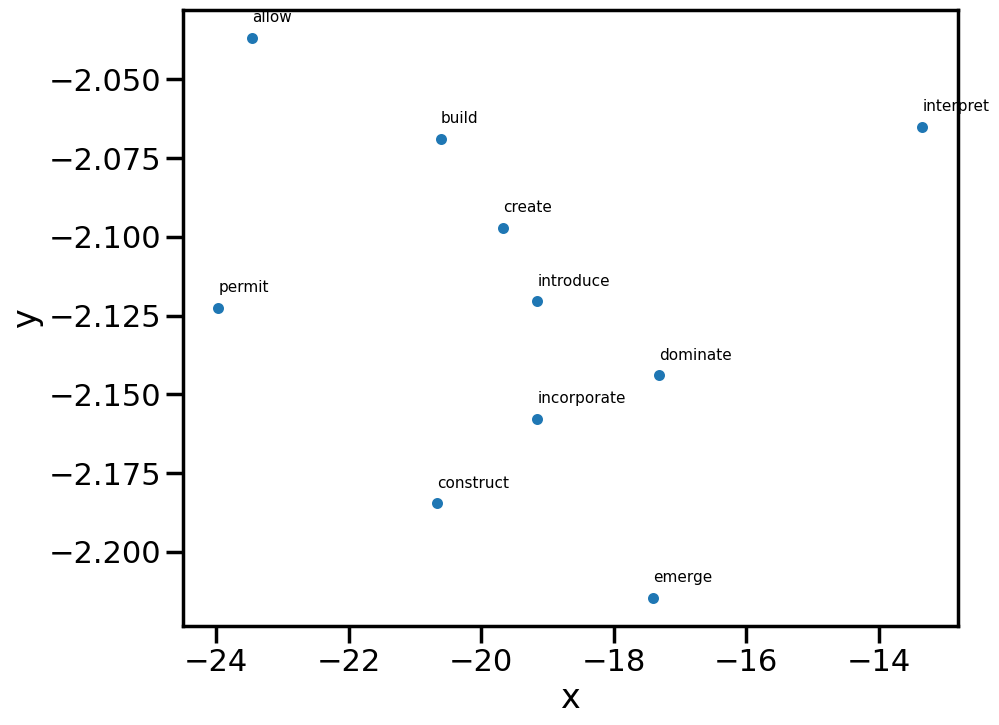

In [ ]:
plot_region(x_bounds=(-25.2, -10.0), y_bounds=(-2.25, -2))

In [ ]:
analogous_words = model.wv.most_similar(positive=['emerge'])
print('\n'.join([str(tup) for tup in analogous_words]))

('dominate', 0.6938037872314453)
('disintegrate', 0.6836696267127991)
('flourish', 0.6796277165412903)
('evolve', 0.6791030764579773)
('coalesce', 0.6589468121528625)
('migrate', 0.6589046120643616)
('migrating', 0.6546440124511719)
('disappear', 0.6486853361129761)
('emerged', 0.6486626863479614)
('grow', 0.6476669907569885)


In [ ]:
analogous_words = model.wv.most_similar('emerge')
print('\n'.join([str(tup) for tup in analogous_words]))

('dominate', 0.6938037872314453)
('disintegrate', 0.6836696267127991)
('flourish', 0.6796277165412903)
('evolve', 0.6791030764579773)
('coalesce', 0.6589468121528625)
('migrate', 0.6589046120643616)
('migrating', 0.6546440124511719)
('disappear', 0.6486853361129761)
('emerged', 0.6486626863479614)
('grow', 0.6476669907569885)


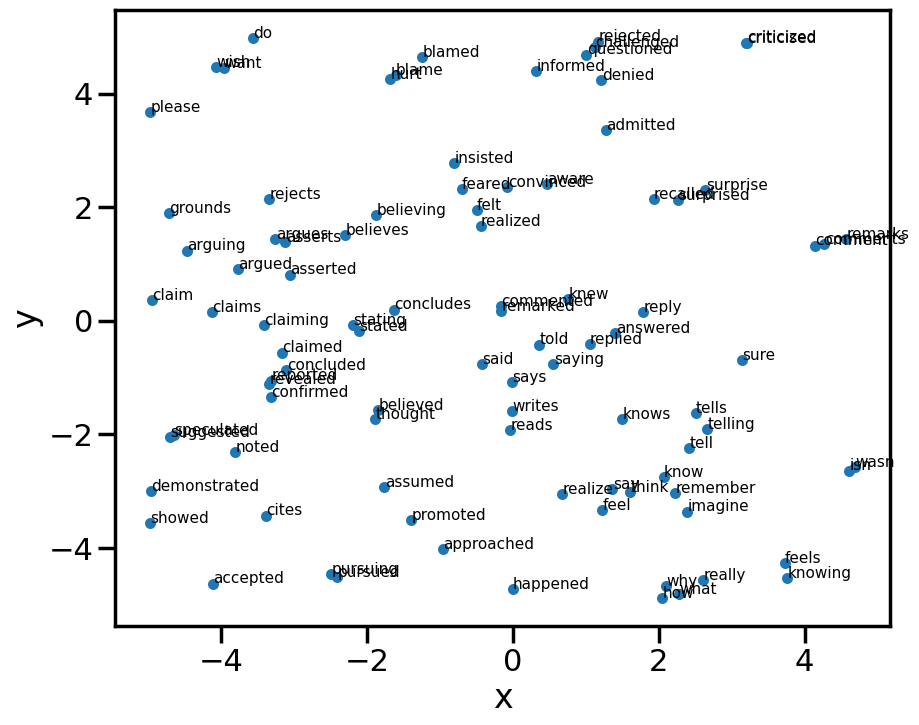

In [ ]:
plot_region(x_bounds=(-5.2, 5.0), y_bounds=(-5.25, 5))

In [ ]:
analogous_words = model.wv.most_similar('say')
print('\n'.join([str(tup) for tup in analogous_words]))

('think', 0.8294373154640198)
('believe', 0.7703351378440857)
('presume', 0.7636426687240601)
('supposing', 0.7495850324630737)
('remarking', 0.7419883012771606)
('know', 0.7390336990356445)
('said', 0.7268357872962952)
('feel', 0.723993718624115)
('shouldn', 0.7220063805580139)
('remember', 0.7214234471321106)


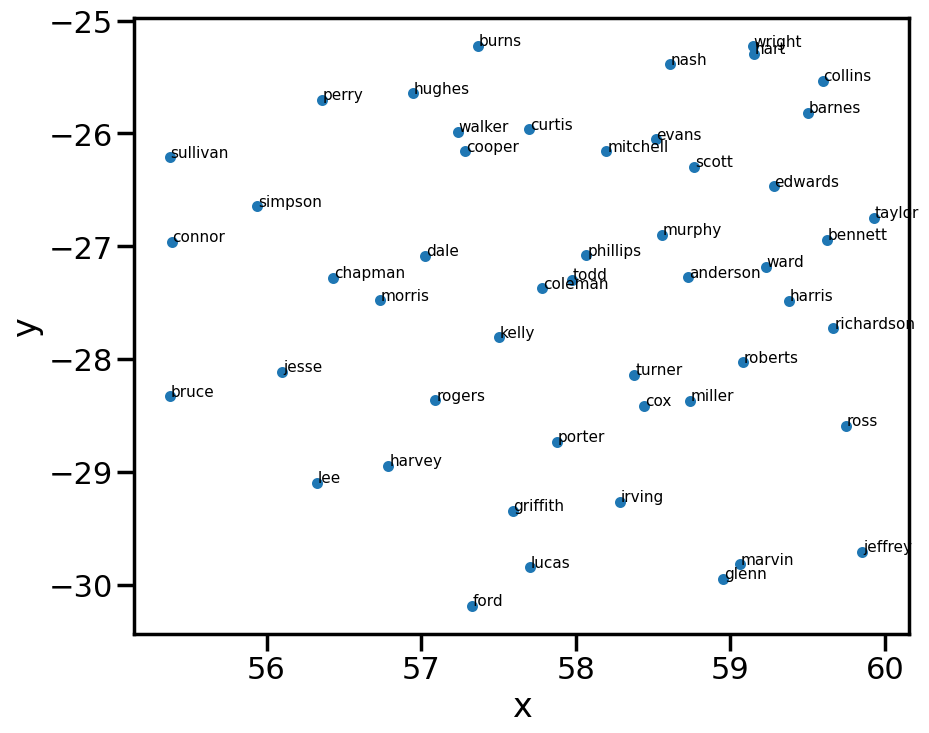

In [ ]:
plot_region(x_bounds=(55.2, 60.0), y_bounds=(-30.25, -25))

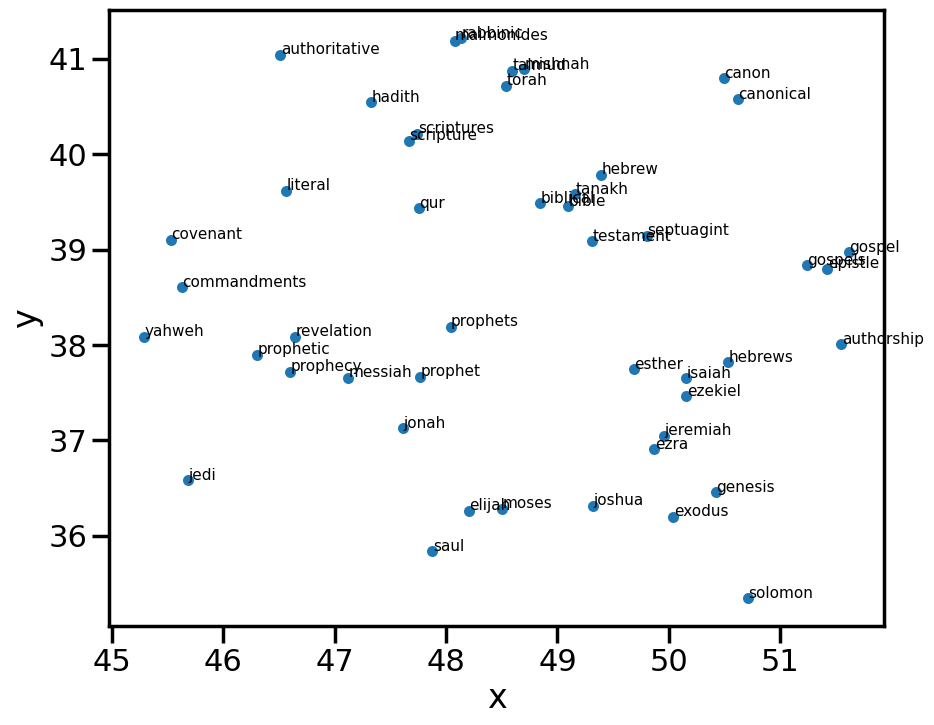

In [ ]:
plot_region(x_bounds=(45, 52.0), y_bounds=(35.25, 42))

## Optional step Extract word vectors from model

The fully trained model includes all of the weights used to predict the context words for each input word. If you are not planning on training the model further, these weights can be discarded, and you can just keep the weights for the word vectors.

In [ ]:
word_vectors2 = model.wv
del model # Delete the whole model to free up the computer's RAM

In [ ]:
word_vectors2.save("word2vec.wordvectors5e")
!zip word2vec.wordvectors5e.zip word2vec.wordvectors5e
!rm word2vec.wordvectors5e

  adding: word2vec.wordvectors5e (deflated 12%)


In [ ]:
!unzip word2vec.wordvectors5e.zip

Archive:  word2vec.wordvectors5e.zip
  inflating: word2vec.wordvectors5e  


In [ ]:
## !rm word2vec.wordvectors

In [ ]:
word_vectors.save("word2vec.wordvectors")
# !zip word2vec.wordvectors.zip word2vec.wordvectors
# !rm word2vec.wordvectors

In [ ]:
del word_vectors

In [ ]:
word_vectors = Word2Vec.load("word2vec.wordvectors")

### Step 3 alternative: download and connect the pre-trained word vectors

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/e7725b1afab9456c8e16/?dl=1
!mv index.html?dl=1 word2vec.wordvectors

In [ ]:
from gensim.models import KeyedVectors

In [ ]:
word_vectors3 = KeyedVectors.load("word2vec.wordvectors5e", mmap='r')

In [ ]:
vector = word_vectors3['computer']
print(vector)
#vector

## Step 1 Using pre-trained models in Gensim

In many applications, you will simply want access to pre-trained word vectors (e.g. for plugging in to another model you are training). If you don't need the vectors to be tailored closely to your particular corpus, then you might like to use some pretrained models.

`word2vec` is not the only word embedding family of algorithms. Another, arguably even more powerful algorithm is the `FastText` algorithm, which Mikolov developed after moving to Facebook:

* Piotr Bojanowski and others, ‘Enriching Word Vectors with Subword Information’, ArXiv:1607.04606, 2017 <http://arxiv.org/abs/1607.04606>.

Instead of computing word vectors for each word, FastText splits each word into its constituent chunks. For example, 'cat' would be split into 'c', 'a', 't', 'ca', 'at' and 'cat', and 'burp' would be split into 'b', 'u', 'r', 'p', 'bu', 'ur', 'rp', 'bur', 'urp' and 'burp'. Then a vector is computer for each chunk that appears in the corpus. Each word is represented as the mean of all the chunks that make it up. FastText is able to learn very good word vectors because it can extract meaning from subword units, e.g. it can see that 'television', 'telegraph' and 'telepathy' all have 'tele' at the front, and can see that 'formality', 'criminality' and 'paucity' share subword units such as 'al' and 'ity'.

You can access many pretrained models using the Gensim downloader. Using the cells below, you can try out some of the different models available through Gensim. Along with `word2vec` and `FastText`, Gensim also supports `Glove` and `Doc2Vec` models.

**NB:** These trained models are very large, and will take a while to download. You may wish to download this notebook and execute the cells below on your own machine, in case Google kicks you out of the Colab environment.

-  downloading a pre-trained Gigaword model, 300 dimensions... (~5 min)

In [ ]:
# word_vectors = api.load('glove-wiki-gigaword-300')

[==================================================] 100.0% 376.1/376.1MB downloaded


- exploring word vectors

There are several ways you can use word vectors. One of the most famous is to use them to compute analogies. The formula is:

<center><em>x</em> is to <em>small</em> as <em>biggest</em> is to <em>big</em></center>

$$x - vector('small') = vector('biggest') - vector('big')$$

$$\therefore x = vector('small') + vector('biggest') - vector('big')$$

### Vector representation of a single word

In [ ]:
# See the word vector for a particular word
vector = word_vectors['banana']
print(vector)

### Finding similar words for a given word vector / word vector combination

In [ ]:
# See which words are closest to a given word in the vector space
# academic words: university, school, college...
similar_words = word_vectors.most_similar('university', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
# colours, spellings
similar_words = word_vectors.most_similar('red', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
similar_words = word_vectors.most_similar('color', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
similar_words = word_vectors.most_similar('colour', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors.most_similar('brussels', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors.most_similar('heidelberg', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors.most_similar('international', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
similar_words = word_vectors.most_similar('school', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
similar_words = word_vectors.most_similar(positive=['heidelberg','international','school'], topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
# geographical names
similar_words = word_vectors.most_similar('germany', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
# adjectives / properties
similar_words = word_vectors.most_similar('strange', topn=25)
print('\n'.join([str(tup) for tup in similar_words]))

### Finding word relations

In [ ]:
# Compute analogous words
# man : king = woman : X
# or
# man : woman = king : X
analogous_words = word_vectors.most_similar(negative=['man'], positive=['king','woman'], topn=20)
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Compute analogous words
#
# E.g. x is to queen as man is to king => x = v('queen') + v('man') - v('king')

analogous_words = word_vectors.most_similar(negative=['king'], positive=['queen','man'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
analogous_words = word_vectors.most_similar(negative=['apple'], positive=['grape','tree'], topn=20)
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
analogous_words = word_vectors.most_similar(negative=['apple'], positive=['berry','tree'], topn=20)
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Compute analogous words
analogous_words = word_vectors.most_similar(negative=['mother'], positive=['father','daughter'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Compute analogous words
analogous_words = word_vectors.most_similar(negative=['mother'], positive=['father','girl'])
print('\n'.join([str(tup) for tup in analogous_words]))

#### Grammatical and derivational relations, language variants...

In [ ]:
# Compute analogous words
# x is to daughter as people is to person (plural + daughter)
analogous_words = word_vectors.most_similar(negative=['person'], positive=['people','daughter'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
analogous_words = word_vectors.most_similar(negative=['person'], positive=['people','child'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
analogous_words = word_vectors.most_similar(negative=['soft'], positive=['hard','softer'])
# analogous_words = word_vectors.most_similar(negative=['soft'], positive=['hard','softest'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
analogous_words = word_vectors.most_similar(negative=['soft'], positive=['hard','softest'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# US/GB
analogous_words = word_vectors.most_similar(negative=['colour'], positive=['favour', 'color'])
print('\n'.join([str(tup) for tup in analogous_words]))

#### Testing the knowledge of world literature ...

In [ ]:
# holmes : sherlock = poirot : X
analogous_words = word_vectors.most_similar(negative=['sherlock'], positive=['holmes','poirot'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# christie : poirot = doyle : X
analogous_words = word_vectors.most_similar(negative=['cristie'], positive=['doyle','poirot'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# homles: doyle = poirot : X
analogous_words = word_vectors.most_similar(negative=['holmes'], positive=['doyle','poirot'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# shakespeare: hamlet = dickens = X
analogous_words = word_vectors.most_similar(negative=['shakespeare'], positive=['macbeth','dickens'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# hamlet: ophelia = romeo : X
analogous_words = word_vectors.most_similar(negative=['hamlet'], positive=['romeo','ophelia'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Romeo : Montague = Juliet : Capulet
# Montague : Romeo = Capulet : Juliet
analogous_words = word_vectors.most_similar(negative=['capulet'], positive=['juliet','montague'])
print('\n'.join([str(tup) for tup in analogous_words]))

#### Colours (colour theory?)

In [ ]:
# green : blue = red : X
analogous_words = word_vectors.most_similar(positive=['yellow', 'red'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# green : blue = red : X
analogous_words = word_vectors.most_similar(negative=['blue'], positive=['green', 'red'])
print('\n'.join([str(tup) for tup in analogous_words]))

#### classes of animals, names for groups of animals (?)

In [ ]:
analogous_words = word_vectors.most_similar(negative=['herd'], positive=['sheep', 'flock'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# * labrador : dog = sparrow : X
analogous_words = word_vectors.most_similar(negative=['labrador'], positive=['dog', 'sparrow']) # bulldog, chair, labrador
print('\n'.join([str(tup) for tup in analogous_words]))

#### Gendered language and gender bias in word embeddings:
- man: actor = woman : X
- man: doctor = woman: X
- man: pilot = woman: X
- man: programmer = woman: X
- man: ambitious = woman: X


In [ ]:
analogous_words = word_vectors.most_similar(negative=['woman'], positive=['actress', 'man'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
analogous_words = word_vectors.most_similar(negative=['men'], positive=['father', 'woman'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# gender bias
# man: doctor = woman: X
analogous_words = word_vectors.most_similar(negative=['man'], positive=['woman', 'doctor'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# woman: doctor / men: X
# nurse - doesn't appear
analogous_words = word_vectors.most_similar(negative=['woman'], positive=['man', 'doctor'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# woman : nurse = man : X
analogous_words = word_vectors.most_similar(negative=['woman'], positive=['nurse', 'man'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# man : nurse = woman : X
# doctor -- doesn't appear
analogous_words = word_vectors.most_similar(negative=['man'], positive=['nurse', 'woman'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# man: director / woman: X
analogous_words = word_vectors.most_similar(negative=['man'], positive=['director', 'woman'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# woman: director / man: X
# assistant - doesn't appear
analogous_words = word_vectors.most_similar(negative=['woman'], positive=['director', 'man'])
print('\n'.join([str(tup) for tup in analogous_words]))

## Step 5. Training models in other languages (Armenian, Georgian, Ukrainian ...)

Now let's train a model on our own corpus. You can try to create Armenian / Ukrainian / Russian / German / French word vector model.

Armenian, Ukrainian, Russian plaintext wikipedias are available at:
https://lindat.mff.cuni.cz/repository/xmlui/handle/11234/1-2735#

We can use the same size ~15 Million Words, (200MB) of these corpora to make sure the model is built within a reasonable time; however, when you have more time, you can try a more complete corpus.

It is possible to download/unzip/upload the files manually, however, it is faster to automatically load them directly from Heidelberg server space https://heibox.uni-heidelberg.de/d/42a07c9e95774e099a81/  into your colab environment. To do this run the cells 5a or 5b, or 5c, or 5d, or 5e -- depending on which language you prefer -- to download the data. Then skip other language and continue with Step5 -- building the model for your preferred language from the data you downloaded.


In [ ]:
!rm /usr/local/lib/python3.10/dist-packages/gensim/test/test_data/myOwnLangText8.txt
!rm index.html?dl=1

rm: cannot remove '/usr/local/lib/python3.10/dist-packages/gensim/test/test_data/myOwnLangText8.txt': No such file or directory
rm: cannot remove 'index.html?dl=1': No such file or directory


### 5c German - works!

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/ca0a085347c34563a6e6/?dl=1

In [ ]:
!cp index.html?dl=1 /usr/local/lib/python3.10/dist-packages/gensim/test/test_data/myOwnLangText8.txt

In [ ]:
!head --lines=15 /usr/local/lib/python3.10/dist-packages/gensim/test/test_data/myOwnLangText8.txt

### Or: 5a Armenian

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/ffe527ed3d1e4b4cb43a/?dl=1

In [ ]:
!cp index.html?dl=1 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

In [ ]:
!head --lines=15 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

### Or: 5b Ukrainian

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/676bef3a6db8482e9665/?dl=1

In [ ]:
!cp index.html?dl=1 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

In [ ]:
!head --lines=15 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

### Or: 5d French

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/5cdb485efd4046f2a457/?dl=1

In [ ]:
!cp index.html?dl=1 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

In [ ]:
!head --lines=15 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

### Or: 5f Georgian

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/fa3509d869b949459f91/?dl=1

Lemmatized corpus

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/b381c458ad5e4773a77d/?dl=1

In [ ]:
!cp index.html?dl=1 wiki_geo_lem.txt

In [ ]:
!head --lines=10 wiki_geo_lem.txt

In [ ]:
FIn = open("wiki_geo_lem.txt", 'r')
FOut = open('wiki_geo_l.txt', 'w')

i = 0
for SLine in FIn:
  i = i + 1
  SLine = SLine.strip() + ' '
  if i % 10000 == 0:
    SLine += '\n'

  FOut.write(SLine)

FOut.flush()
FOut.close()


In [ ]:
!head --lines=10 wiki_geo_l.txt

In [ ]:
!wc wiki_geo_lem.txt

 18054750  18054749 329202500 wiki_geo_lem.txt


In [ ]:
!cp index.html?dl=1 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

Alternatively, copy lemmatized corpus

In [ ]:
!cp wiki_geo_l.txt /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

In [ ]:
!head --lines=15 /usr/local/lib/python3.7/dist-packages/gensim/test/test_data/myOwnLangText8.txt

### Stage6: Training own model

optional: to clean disk space, we remove the downloaded file

In [ ]:
# optional: to clean disk space, we remove the downloaded file
!rm index.html\?dl\=1

In [ ]:
from gensim.test.utils import datapath
from gensim import utils

class MyCorpus:
    """An iterator that yields sentences (lists of str)."""

    def __iter__(self):
        corpus_path = datapath('myOwnLangText8.txt')
        for line in open(corpus_path):
            # assume there's one document per line, tokens separated by whitespace
            yield utils.simple_preprocess(line)

In [ ]:
import gensim.models
corpusOwn = MyCorpus()

optional: examining what is in the corpus after standard preprocessing

In [ ]:
# Optional: Examining our corpus format
type(corpusOwn)

In [ ]:
dataOwn = [d for d in corpusOwn]

In [ ]:
print(len(dataOwn))
print(dataOwn[0])
print(len(dataOwn[0]))
print(dataOwn[4])
print(len(dataOwn[4]))
print(dataOwn[5])
print(len(dataOwn[5]))

... Initialising global parameters for our modelL vector size, collocation window, skip-grams, negative sampling....

In [ ]:
from gensim.models import Word2Vec # The word2vec model class
import gensim.downloader as api # Allows us to download some free training data

In [ ]:
my_vector_size = 100 # Dimensionality of the word vectors
window = 5 # How many words either side? (5 = 5 context words either side, i.e. 10 context words in total)
use_skip_gram = 1 # If you set this to 0, then it will create a 'continuous bag of words' model instead
use_softmax = 0 # If you set this to 1, then hierarchical softmax will be used instead of negative sampling
negative_samples = 5 # How many incorrect answers to generate per correct answer when negative sampling

modelOwn = Word2Vec(
    vector_size=my_vector_size,
    window=window,
    sg=use_skip_gram,
    hs=use_softmax,
    negative=negative_samples
)

... this cell may run for ~2 min or so...

In [ ]:
modelOwn.build_vocab(corpusOwn)

THIS MAY TAKE LONG!!! ... training the model may take 9 to 15 minutes... (just grab a cup of coffee or a sandwich while you are waiting... You may try chaning the number of epochs; if the number is lower the training is faster, but the quality may be lower...

In [ ]:
modelOwn.train(corpusOwn, epochs=5, total_examples=modelOwn.corpus_count)

(56967743, 75507725)

Now we copy word vectors and remove the model from memory (just to free up the resources...)

In [ ]:
# saving model
modelOwn.save("word2vecGerman5e.model")
!zip word2vecGerman5e.model.zip word2vecGerman5e.model word2vecGerman5e.model.syn1neg.npy word2vecGerman5e.model.wv.vectors.npy
# !rm word2vecGerman5e.model

In [ ]:
# extracting vectors from the model

In [ ]:
word_vectors_own = modelOwn.wv

In [ ]:
# del modelOwn

In [ ]:
word_vectors_own.save("word2vec.wordvectorsGerman5e")
!zip word2vec.wordvectorsGerman5e.zip word2vec.wordvectorsGerman5e word2vec.wordvectorsGerman5e.vectors.npy
# !rm word2vec.wordvectorsGerman5e

#### alternative: donloading pre-trained word vectors

In [ ]:
!wget https://heibox.uni-heidelberg.de/f/359e4cc37be8449fa142/?dl=1
!mv index.html?dl=1 word2vec.wordvectorsGerman5e.zip
!unzip word2vec.wordvectorsGerman5e.zip




In [ ]:
from gensim.models import KeyedVectors
word_vectors_own = KeyedVectors.load("word2vec.wordvectorsGerman5e", mmap='r')

Now we can examine the output of our word embeddings

### German examples

In [ ]:
# DE examples
# See the word vector for a particular word
vector = word_vectors_own['banane']
print(vector)

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors_own.most_similar('universität', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors_own.most_similar('rot', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors_own.most_similar('brüssel', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors_own.most_similar('deutschland', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# See which words are closest to a given word in the vector space
similar_words = word_vectors_own.most_similar('komisch', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# Compute analogous words
# E.g. x is to queen as man is to king => x = v('queen') + v('man') - v('king')
analogous_words = word_vectors_own.most_similar(negative=['mann'], positive=['könig','frau'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Compute analogous words
# E.g. x is to queen as man is to king => x = v('queen') + v('man') - v('king')
analogous_words = word_vectors_own.most_similar(negative=['könig'], positive=['königin','mann'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Compute analogous words
# E.g. x is to queen as man is to king => x = v('queen') + v('man') - v('king')
analogous_words = word_vectors_own.most_similar(negative=['mutter'], positive=['vater','tochter'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Compute analogous words
# E.g. x is to queen as man is to king => x = v('queen') + v('man') - v('king')
analogous_words = word_vectors_own.most_similar(negative=['mutter'], positive=['vater','mädchen'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# Compute analogous words
# x is to daughter as people is to person (plural + daughter)
analogous_words = word_vectors_own.most_similar(negative=['person'], positive=['menschen','tochter'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
analogous_words = word_vectors_own.most_similar(negative=['weich'], positive=['hart','weicher'])
print('\n'.join([str(tup) for tup in analogous_words]))

### Georgian examples

In [ ]:
# See the word vector for a particular word -- 'world'
vector = word_vectors_own['სამყარო']
print(vector)

In [ ]:
# See which words are closest to a given word in the vector space = 'world'
similar_words = word_vectors_own.most_similar('არსება', topn=30)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# blue
similar_words = word_vectors_own.most_similar('ლურჯი', topn=30)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# france
similar_words = word_vectors_own.most_similar('საფრანგეთი', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# x is to king as woman is to man
analogous_words = word_vectors_own.most_similar(negative=['კაცი'], positive=['მეფე','ქალი'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# x is to king as woman is to man
# x = small + biggest - big
# 𝑥−𝑣𝑒𝑐𝑡𝑜𝑟(′𝑠𝑚𝑎𝑙𝑙′)=𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔𝑔𝑒𝑠𝑡′)−𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔′)
# ∴ 𝑥=𝑣𝑒𝑐𝑡𝑜𝑟(′𝑠𝑚𝑎𝑙𝑙′)+𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔𝑔𝑒𝑠𝑡′)−𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔′)
# ∴ 𝑥=𝑣𝑒𝑐𝑡𝑜𝑟(′փոքր′)+𝑣𝑒𝑐𝑡𝑜𝑟(′ամենամեծը′)−𝑣𝑒𝑐𝑡𝑜𝑟(′մեծ′)
analogous_words = word_vectors_own.most_similar(negative=['პირი'], positive=['ხალხი','ქალიშვილი'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# try your own examples... (also -- morphology?)
# # x is to daughter as people is to person (plural + daughter)
# analogous_words = word_vectors.most_similar(negative=['person'], positive=['people','daughter'])

### Armenian examples

In [ ]:
# See the word vector for a particular word -- 'world'
vector = word_vectors_own['աշխարհը']
print(vector)

In [ ]:
# See which words are closest to a given word in the vector space = 'world'
similar_words = word_vectors_own.most_similar('աշխարհը', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# blue
similar_words = word_vectors_own.most_similar('կապույտ', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# france
similar_words = word_vectors_own.most_similar('ֆրանսիա', topn=10)
print('\n'.join([str(tup) for tup in similar_words]))

In [ ]:
# x is to king as woman is to man
analogous_words = word_vectors_own.most_similar(negative=['մարդ'], positive=['թագավոր','կին'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# x is to king as woman is to man
# x = small + biggest - big
# 𝑥−𝑣𝑒𝑐𝑡𝑜𝑟(′𝑠𝑚𝑎𝑙𝑙′)=𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔𝑔𝑒𝑠𝑡′)−𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔′)
# ∴ 𝑥=𝑣𝑒𝑐𝑡𝑜𝑟(′𝑠𝑚𝑎𝑙𝑙′)+𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔𝑔𝑒𝑠𝑡′)−𝑣𝑒𝑐𝑡𝑜𝑟(′𝑏𝑖𝑔′)
# ∴ 𝑥=𝑣𝑒𝑐𝑡𝑜𝑟(′փոքր′)+𝑣𝑒𝑐𝑡𝑜𝑟(′ամենամեծը′)−𝑣𝑒𝑐𝑡𝑜𝑟(′մեծ′)
analogous_words = word_vectors_own.most_similar(negative=['մեծ'], positive=['ամենամեծը','փոքր'])
print('\n'.join([str(tup) for tup in analogous_words]))

In [ ]:
# try your own examples... (also -- morphology?)
# # x is to daughter as people is to person (plural + daughter)
# analogous_words = word_vectors.most_similar(negative=['person'], positive=['people','daughter'])